In [34]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap


d:\Tesis\icafs\icafs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load data set

In [12]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

unique_names_algarrobo = df_algarrobo['Labels'].unique()
algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]




unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_20036\1024705498.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
C:\Users\robma\AppData\Local\Temp\ipykernel_20036\1024705498.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
C:\Users\robma\AppData\Local\Temp\ipykernel_20036\1024705498.py:32: FutureWarning: Downcasting behavio

In [35]:
def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,model, print_logs=False):

  max_it = 1 
  score_list = []
  featur_list = []
  iter_list = []
  
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,model)
  while max_iteartion_aux > 0:

      dict_parameters = {}
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = dataset_X[list_attributes_to_consider]
          clf_new = train_model(model)
          score = cross_val_score(clf_new,df_temp.values, dataset_Y.values.ravel(), cv=5, scoring='f1_macro')
          final_score = score.mean()

          if final_score >= partial_score :
              partial_score = final_score
              best_data_set = list_attributes_to_consider.copy()
          clf_new = None
      #best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      iter_list.append(max_it)
      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
  return iter_list,featur_list,score_list

def initial_test_training(score_list, iter_list, feature_list ,X,y,model):
     clf_new = train_model(model)
     score = cross_val_score(clf_new,X.values, y.values.ravel(), cv=5, scoring='f1_macro')
     score_list.append(score.mean())
     feature_list.append(X.shape[1])
     iter_list.append(0)

def train_model(model_name):  
    m = eval(model_name)
    return m

In [36]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
       
        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

In [13]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


def plot_original_vs_reduced_umap(df_reduced_dataset,df_complete, y_dataset_integer,unique_classes):
    umap_3d = umap.UMAP(n_components=3)
    
    X_reduced_standarized = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete_standarized  = StandardScaler().fit_transform(df_complete)
    
    reduced_umap = umap_3d.fit_transform(X_reduced_standarized)
    complete_umap = umap_3d.fit_transform(X_complete_standarized)
  
    fig = plt.figure(figsize=plt.figaspect(0.5))
    y_dataset_flatten = y_dataset_integer.values.ravel()

    print(unique_classes)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
    plt.legend()
    #ax.scatter(complete_umap[:,0], complete_umap[:,1], complete_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(reduced_umap[indices,0], reduced_umap[indices,1], reduced_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])

    #ax.scatter(reduced_umap[:,0], reduced_umap[:,1], reduced_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    plt.legend()
    
    plt.show()
   

# ICAFS KNN

best f1 score= 0.9017056611956772, iteration:1, numbers features selected =799,best features selected=1103, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1718, 1720, 1721, 1722, 1723, 1724, 1725, 1726, 1728, 1729, 1730, 1731, 1732, 1733, 1734, 1735, 1736, 1737, 1738, 1739, 1740, 1741, 1742, 1743, 1744, 1745, 1746, 1747, 1748, 1749, 1750, 1752, 1753, 1754, 1755, 1756, 1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764, 1765, 1766, 1767, 1768, 1769, 1770, 1771, 1772, 1773, 1774, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1848, 1849

<Figure size 1100x1000 with 0 Axes>

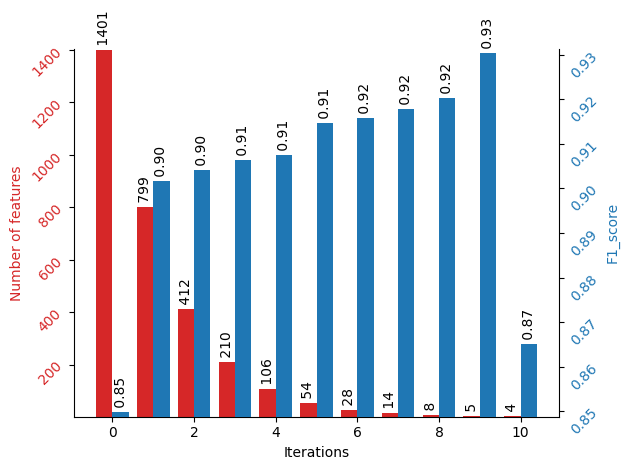

In [20]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cacao,y_cacao,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cacao_knn_icafs.png')

best f1 score= 0.7351370100315423, iteration:1, numbers features selected =9,best features selected=NGRDI, NDVI, RVI, DVI, EVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.7216630322908072, iteration:2, numbers features selected =6,best features selected=NGRDI, NDVI, RVI, EVI, NDRE, REDVI
best f1 score= 0.717571263976013, iteration:3, numbers features selected =4,best features selected=NGRDI, NDVI, RVI, NDRE
best f1 score= 0.7092041147580356, iteration:4, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:5, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:6, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:7, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:8, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best 

<Figure size 1100x1000 with 0 Axes>

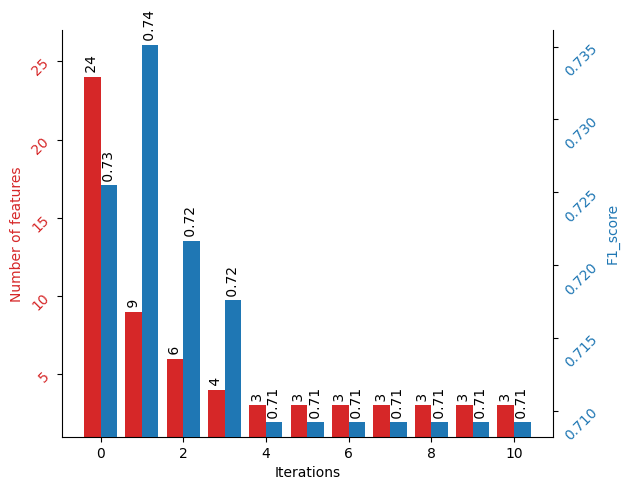

In [19]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['N' 'P']


C:\Users\robma\AppData\Local\Temp\ipykernel_20036\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_20036\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

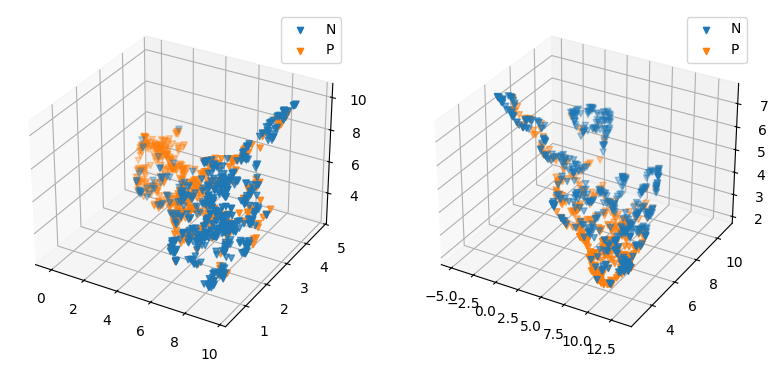

In [10]:
plot_original_vs_reduced_umap(X_algarrobo[['NGRDI', 'NDVI', 'RVI']],X_algarrobo,y_algarrobo,unique_names_algarrobo)

best f1 score= 0.9571730048089891, iteration:1, numbers features selected =156,best features selected=907.047, 1018.987, 1026.707, 1030.567, 1034.427, 1038.287, 1042.147, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1065.307, 1069.167, 1073.027, 1076.887, 1080.747, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526,

<Figure size 1100x1000 with 0 Axes>

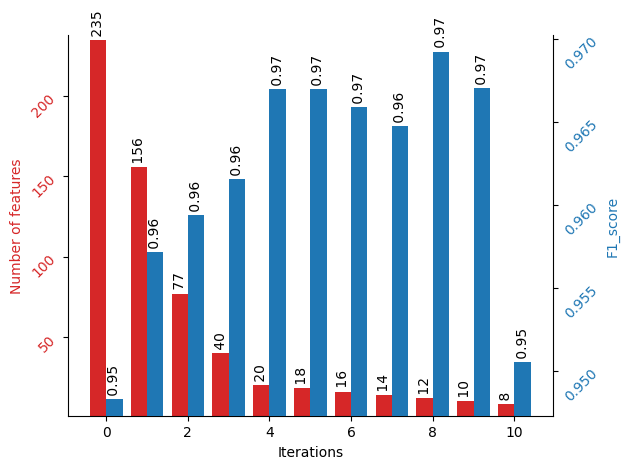

In [30]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Not Strawberry' 'Strawberry']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

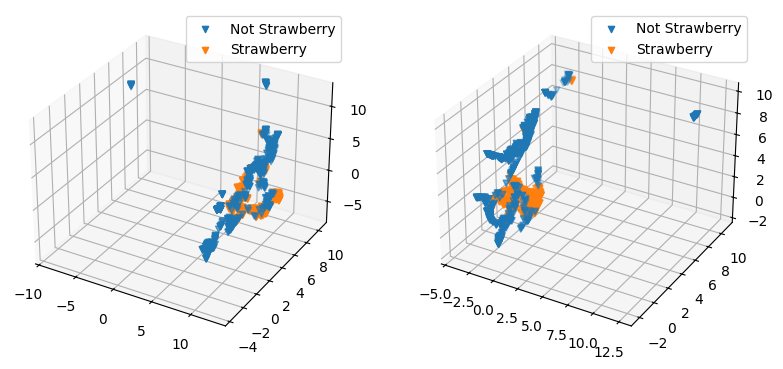

In [54]:
plot_original_vs_reduced_umap(X_fruit_puree[['1404.985', '1443.585', '1474.465', '1516.925', '1609.565', '1679.044', '1771.684', '1802.564']],X_fruit_puree,y_fruit_puree,unique_names_berry)

best f1 score= 0.9747027699968877, iteration:1, numbers features selected =270,best features selected=1018.856, 1344.9525, 1346.882, 1348.8115, 1350.741, 1352.6705, 1354.6, 1356.5295, 1358.459, 1360.3885, 1362.318, 1364.2485, 1366.178, 1368.1075, 1370.037, 1371.9665, 1375.8255, 1377.755, 1379.6845, 1381.614, 1383.5435, 1385.473, 1387.4025, 1389.332, 1391.2615, 1393.191, 1395.1205, 1397.05, 1398.9805, 1400.91, 1402.8395, 1404.769, 1406.6985, 1408.628, 1410.5575, 1412.487, 1414.4165, 1416.346, 1418.2755, 1420.205, 1422.1345, 1424.064, 1425.9935, 1427.923, 1429.8525, 1431.782, 1433.7125, 1435.642, 1437.5715, 1439.501, 1441.4305, 1443.36, 1445.2895, 1447.219, 1449.1485, 1451.078, 1453.0075, 1454.937, 1456.8675, 1458.797, 1460.7265, 1462.656, 1464.5855, 1468.4445, 1470.374, 1472.3035, 1474.233, 1476.1625, 1478.092, 1480.0215, 1481.951, 1483.8805, 1485.81, 1487.7395, 1489.669, 1491.5995, 1493.529, 1495.4585, 1499.3175, 1501.247, 1503.1765, 1505.106, 1507.0355, 1508.965, 1510.8945, 1512.824, 

<Figure size 1100x1000 with 0 Axes>

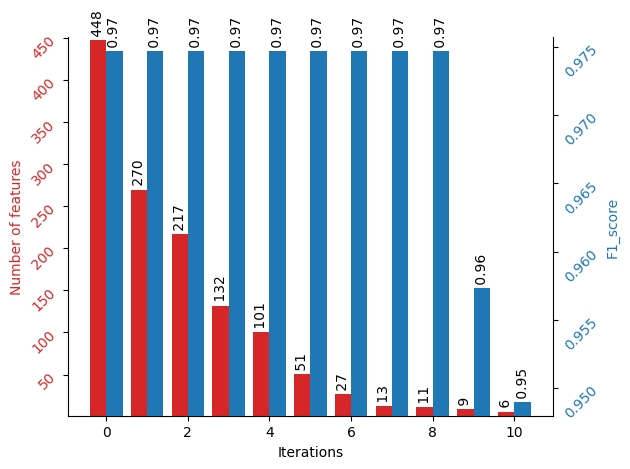

In [32]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Chicken' 'Pork' 'Turkey']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

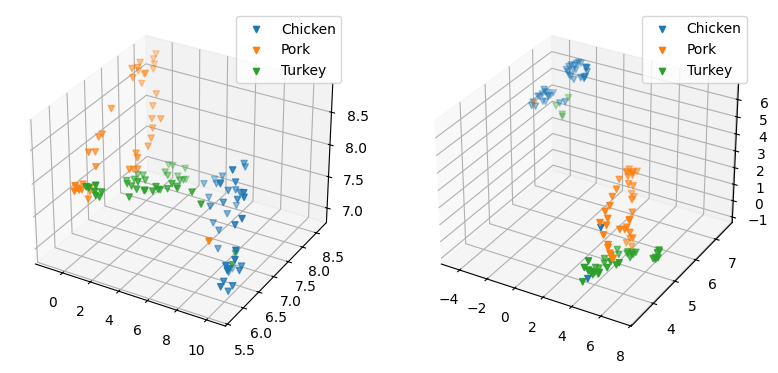

In [65]:
plot_original_vs_reduced_umap(X_meat[['1634.3875', '1713.499', '1719.2875', '1746.3015', '1836.991', '1842.7805']], X_meat,y_meat,unique_names_meat)

best f1 score= 0.8873252371123888, iteration:1, numbers features selected =287,best features selected=802.751, 827.8345, 831.6935, 833.623, 835.5525, 837.482, 839.4115, 841.341, 843.2705, 845.2, 847.1295, 849.059, 850.9885, 852.918, 854.8475, 856.777, 858.7065, 860.636, 868.354, 870.2835, 872.213, 876.072, 881.8605, 883.79, 885.7195, 887.649, 891.508, 893.4375, 895.367, 905.0145, 908.8735, 910.803, 920.4505, 928.1685, 930.098, 932.0275, 933.957, 937.816, 943.6045, 945.534, 947.4645, 949.394, 953.253, 955.1825, 957.112, 966.7595, 970.6185, 972.548, 974.4775, 982.1955, 989.9135, 991.843, 993.7725, 995.702, 999.561, 1007.279, 1009.2085, 1011.138, 1014.997, 1016.9265, 1018.856, 1028.5035, 1032.3625, 1034.292, 1036.2215, 1043.9405, 1051.6585, 1053.588, 1055.5175, 1057.447, 1061.306, 1069.024, 1070.9535, 1072.883, 1076.743, 1078.6725, 1080.602, 1090.2495, 1094.1085, 1096.038, 1097.9675, 1105.6855, 1113.4045, 1115.334, 1117.2635, 1119.193, 1123.052, 1130.77, 1132.7005, 1134.63, 1138.489, 1140

<Figure size 1100x1000 with 0 Axes>

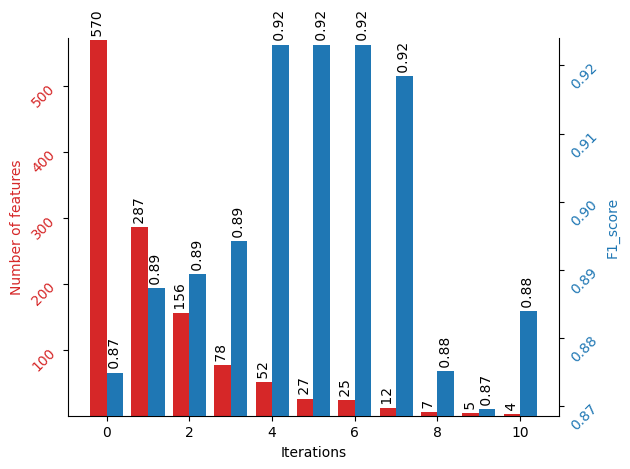

In [34]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Greece' 'Italy' 'Portugal' 'Spain']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

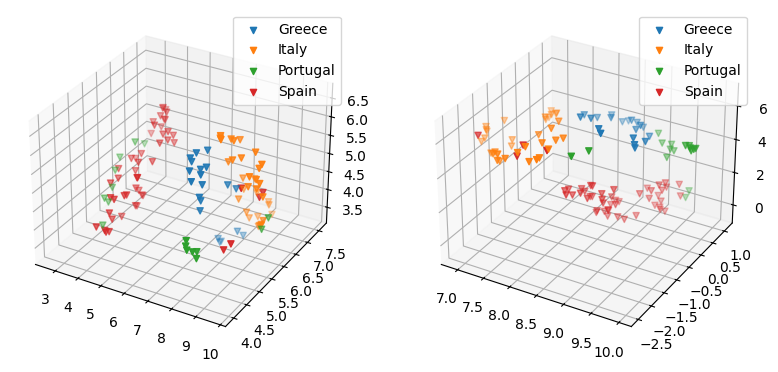

In [35]:
plot_original_vs_reduced_umap(X_olive[['1032.3625', '1130.77', '1180.939', '1217.6005', '1261.981', '1370.037', '1427.923', '1464.5855', '1508.965', '1617.021', '1674.908']],X_olive,y_olive,unique_names_olive)

best f1 score= 0.9790925773245351, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9902991873397463, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9902991873397463, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

<Figure size 1100x1000 with 0 Axes>

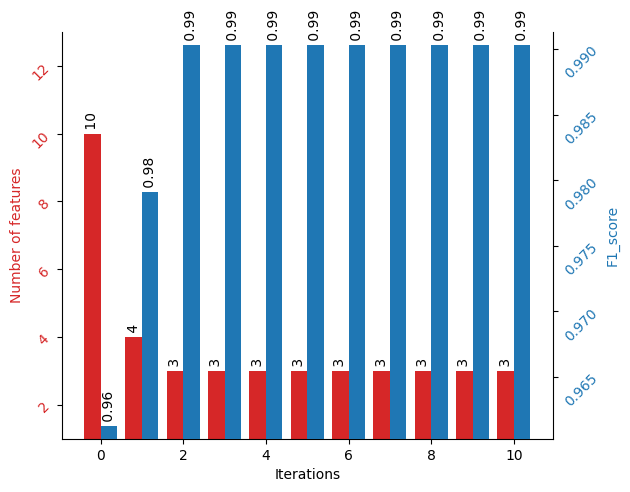

In [11]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'KNeighborsClassifier(n_neighbors=3)',True)
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

# ICAFS SVC

best f1 score= 0.6737857229528509, iteration:1, numbers features selected =703,best features selected=1101, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1119, 1121, 1122, 1123, 1124, 1126, 1128, 1133, 1135, 1137, 1138, 1139, 1140, 1142, 1143, 1144, 1149, 1153, 1154, 1155, 1156, 1158, 1159, 1160, 1165, 1169, 1170, 1171, 1172, 1174, 1175, 1176, 1181, 1185, 1186, 1187, 1188, 1190, 1191, 1192, 1197, 1201, 1202, 1203, 1204, 1206, 1207, 1208, 1213, 1217, 1218, 1219, 1220, 1222, 1223, 1224, 1229, 1233, 1234, 1235, 1236, 1238, 1239, 1240, 1245, 1249, 1250, 1251, 1252, 1254, 1255, 1256, 1261, 1265, 1266, 1267, 1268, 1270, 1271, 1272, 1277, 1281, 1282, 1283, 1284, 1286, 1287, 1288, 1293, 1297, 1298, 1299, 1300, 1302, 1303, 1304, 1309, 1313, 1314, 1315, 1316, 1318, 1319, 1320, 1325, 1329, 1330, 1331, 1332, 1334, 1335, 1336, 1341, 1345, 1346, 1347, 1348, 1350, 1351, 1352, 1357, 1361, 1362, 1363, 1364, 1366, 1367, 1368, 1373, 1377, 1378, 1379, 1380, 1382, 1383, 1384, 1389, 1393, 1394, 1395

<Figure size 1100x1000 with 0 Axes>

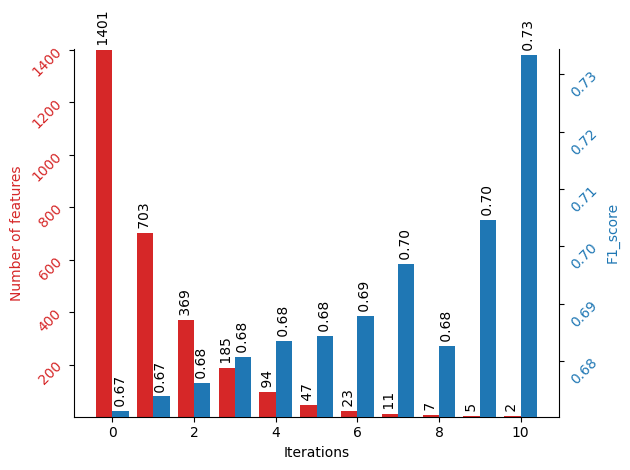

In [37]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'svm.SVC()' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_svc_icafs.png')

best f1 score= 0.7390899498005483, iteration:1, numbers features selected =12,best features selected=Edge Red, CIVE, VEG, RGBVI, MGRVI, NDVI, RVI, DVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.7472275511961944, iteration:2, numbers features selected =7,best features selected=Edge Red, CIVE, VEG, MGRVI, RVI, REVI, RERVI
best f1 score= 0.7523170717720014, iteration:3, numbers features selected =5,best features selected=Edge Red, CIVE, VEG, RVI, RERVI
best f1 score= 0.7452878552552512, iteration:4, numbers features selected =4,best features selected=Edge Red, CIVE, VEG, RERVI
best f1 score= 0.7485400164811925, iteration:5, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:6, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:7, numbers features selected =3,best features selected=Edge Red, CIVE, VEG
best f1 score= 0.7485400164811925, iteration:8, numbers fea

<Figure size 1100x1000 with 0 Axes>

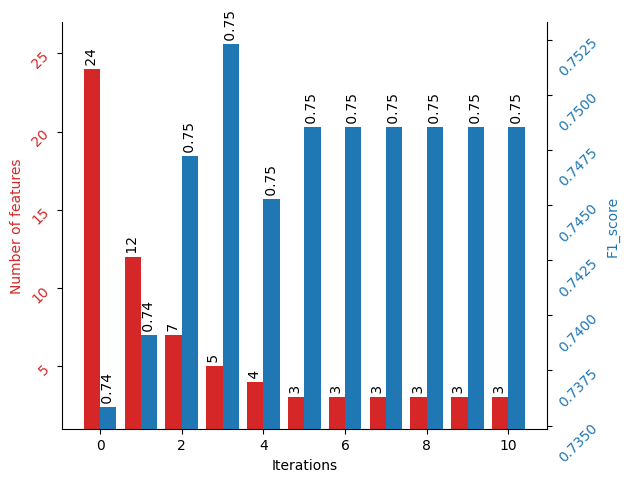

In [38]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'svm.SVC()',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_svc_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['N', 'P']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

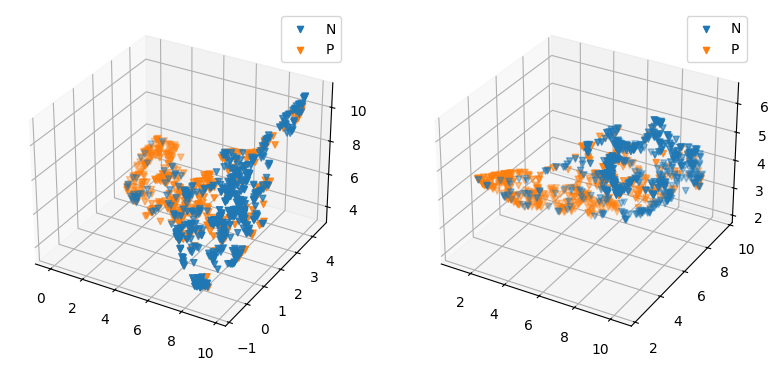

In [39]:
plot_original_vs_reduced_umap(X_algarrobo[['Edge Red', 'CIVE', 'VEG', 'RVI', 'RERVI']], X_algarrobo,y_algarrobo,['N', 'P'])

best f1 score= 0.9530766413392759, iteration:1, numbers features selected =156,best features selected=907.047, 1018.987, 1026.707, 1030.567, 1034.427, 1038.287, 1042.147, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1065.307, 1069.167, 1073.027, 1076.887, 1080.747, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526,

<Figure size 1100x1000 with 0 Axes>

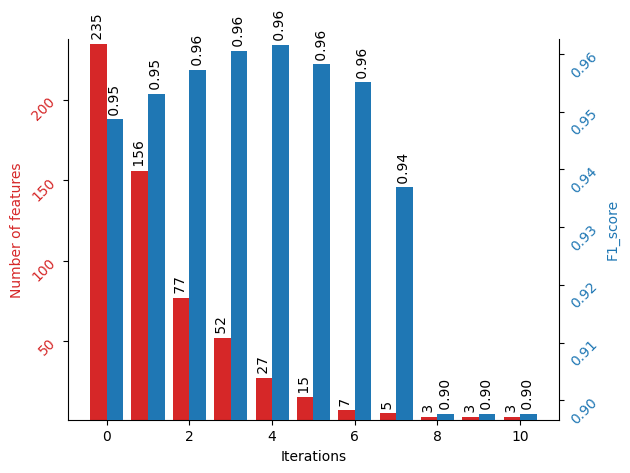

In [40]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_svc_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Not Strawberry' 'Strawberry']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

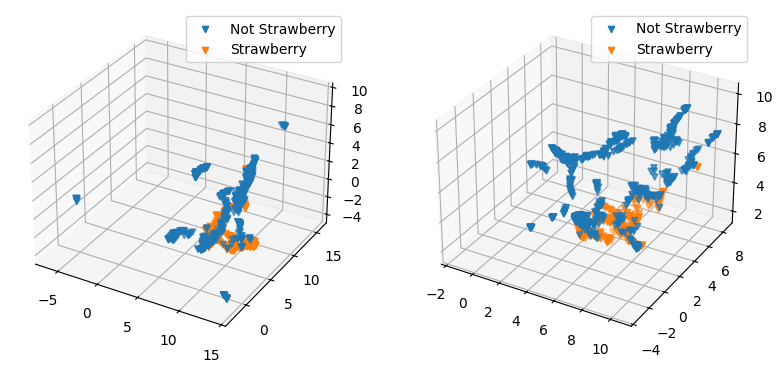

In [41]:
plot_original_vs_reduced_umap(X_fruit_puree[['1088.467', '1188.826', '1250.586', '1377.966', '1559.385']], X_fruit_puree,y_fruit_puree,unique_names_berry)

best f1 score= 0.8566204914460063, iteration:1, numbers features selected =465,best features selected=812.3985, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 935.8865, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1038.151, 1040.0815, 1042.011, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067

<Figure size 1100x1000 with 0 Axes>

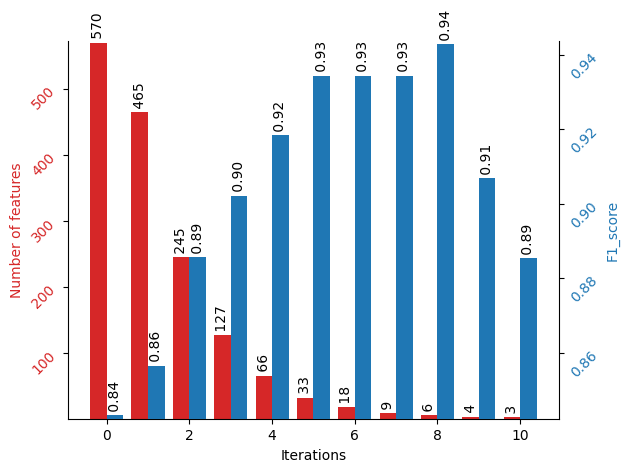

In [42]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs_svc.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Greece' 'Italy' 'Portugal' 'Spain']


C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_14908\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_uma

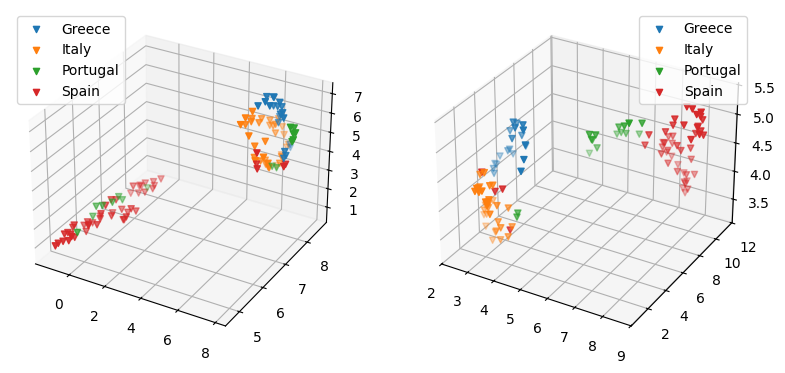

In [43]:
plot_original_vs_reduced_umap(X_olive[['968.689', '1126.911', '1250.404', '1470.374', '1603.5135', '1732.795']], X_olive,y_olive,unique_names_olive)

best f1 score= 0.9747027699968877, iteration:1, numbers features selected =175,best features selected=1009.2085, 1528.261, 1532.12, 1534.0495, 1535.979, 1537.9085, 1539.838, 1541.7675, 1543.697, 1545.6265, 1547.556, 1549.4865, 1551.416, 1553.3455, 1555.275, 1557.2045, 1559.134, 1561.0635, 1562.993, 1564.9225, 1566.852, 1568.7815, 1570.711, 1572.6415, 1574.571, 1576.5005, 1578.43, 1580.3595, 1582.289, 1584.2185, 1586.148, 1590.007, 1593.866, 1595.7955, 1597.725, 1599.6545, 1601.584, 1603.5135, 1605.443, 1607.3735, 1609.303, 1611.2325, 1613.162, 1615.0915, 1617.021, 1618.9505, 1620.88, 1622.8095, 1624.739, 1626.6685, 1628.598, 1630.5285, 1632.458, 1634.3875, 1636.317, 1638.2465, 1640.176, 1642.1055, 1644.035, 1645.9645, 1647.894, 1649.8235, 1651.753, 1653.6825, 1655.612, 1657.5415, 1659.471, 1661.4005, 1663.33, 1665.2605, 1667.19, 1669.1195, 1671.049, 1672.9785, 1674.908, 1676.8375, 1678.767, 1680.6965, 1682.626, 1684.5555, 1686.485, 1688.4155, 1690.345, 1692.2745, 1694.204, 1696.1335, 1

<Figure size 1100x1000 with 0 Axes>

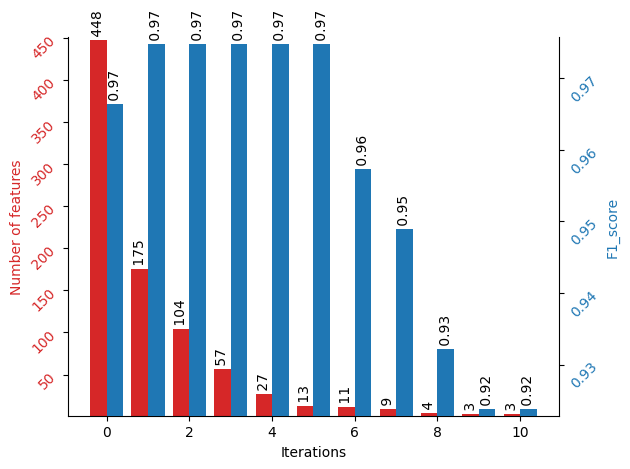

In [44]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_icafs_svc.png')

best f1 score= 0.9695785638039212, iteration:1, numbers features selected =6,best features selected=X, Y, X10, X20, X30, X40
best f1 score= 0.9726812692225117, iteration:2, numbers features selected =4,best features selected=X, Y, X10, X30
best f1 score= 0.9749848089846103, iteration:3, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:4, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:5, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:6, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:7, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:8, numbers features selected =3,best features selected=X, Y, X10
best f1 score= 0.9749848089846103, iteration:9, numbers features selected =3,best features selected=

<Figure size 1100x1000 with 0 Axes>

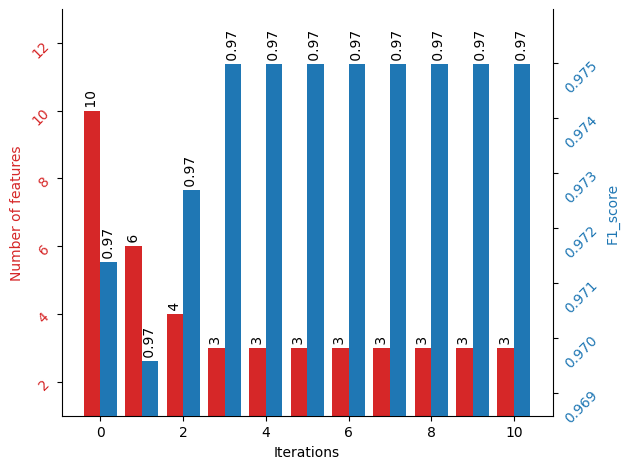

In [45]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

# ICAFS MLP

best f1 score= 0.9848348774835373, iteration:1, numbers features selected =1115,best features selected=1103, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331, 1332, 1333, 1334, 133

<Figure size 1100x1000 with 0 Axes>

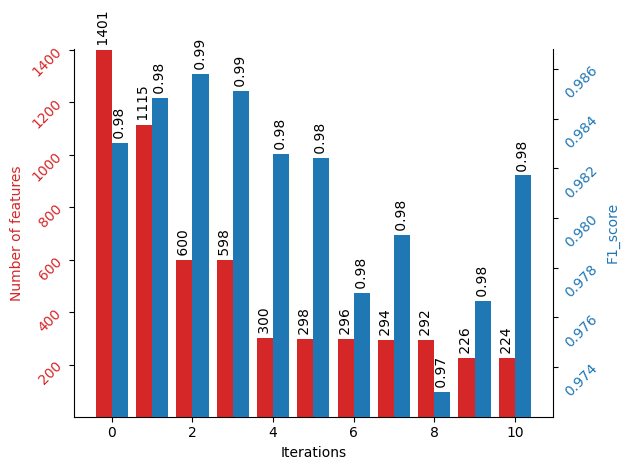

In [46]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_mlp_icafs.png')

best f1 score= 0.7350254038948781, iteration:1, numbers features selected =12,best features selected=R, Edge Red, EXG, NGRDI, RGRI, GBRI.1, VEG, MGRVI, RVI, EVI, NDRE, REDVI
best f1 score= 0.7465328841761708, iteration:2, numbers features selected =6,best features selected=R, NGRDI, GBRI.1, MGRVI, EVI, REDVI
best f1 score= 0.7343662256882106, iteration:3, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7284994034170131, iteration:4, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7342949760896413, iteration:5, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7255579193118072, iteration:6, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7314142730660524, iteration:7, numbers features selected =3,best features selected=R, MGRVI, REDVI
best f1 score= 0.7273013612142012, iteration:8, numbers features selected =3,best features selected=R, MGRVI, 

<Figure size 1100x1000 with 0 Axes>

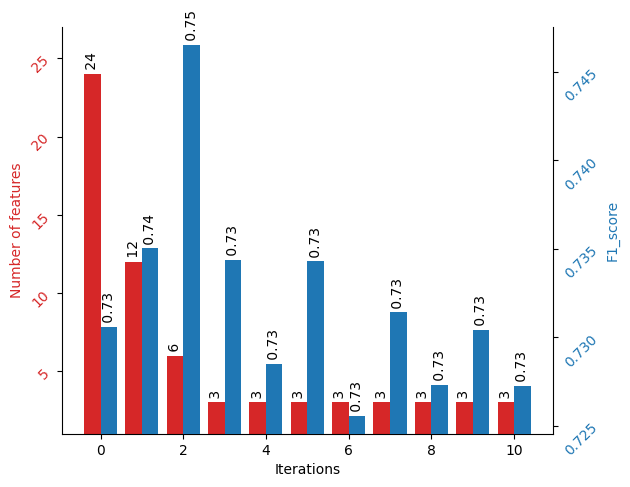

In [47]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_mlp_icafs.png')

best f1 score= 0.9563755795668023, iteration:1, numbers features selected =4,best features selected=X, Y, X40, Y40
best f1 score= 0.9568738092693945, iteration:2, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9570726999799813, iteration:3, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9565710250116798, iteration:4, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9565713848812873, iteration:5, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9577728307381752, iteration:6, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9580740353299433, iteration:7, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9566727946717334, iteration:8, numbers features selected =3,best features selected=X, Y, Y40
best f1 score= 0.9564724518160042, iteration:9, numbers features selected =3,best features selected=X, Y, Y40
best 

<Figure size 1100x1000 with 0 Axes>

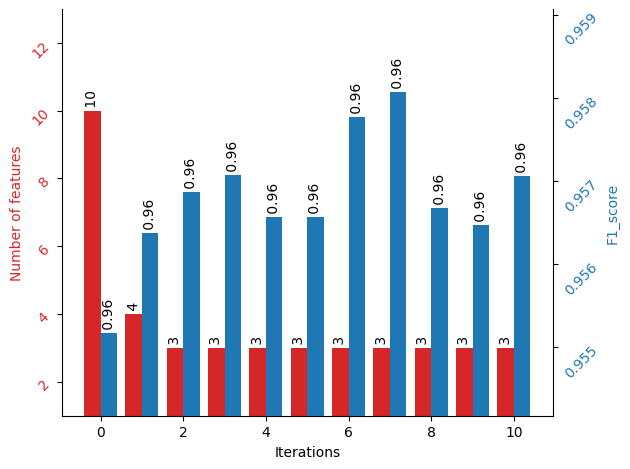

In [48]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_mlp_icafs.png')

best f1 score= 0.9454067149361615, iteration:1, numbers features selected =154,best features selected=907.047, 1204.266, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1327.786, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526, 1366.386, 1370.246, 1374.106, 1377.966, 1381.826, 1385.686, 1389.545, 1393.405, 1397.265, 1401.125, 1404.985, 1408.845, 1412.705, 1416.565, 1420.425, 1424.285, 1428.145, 1432.005, 1435.865, 1439.725, 1443.585, 1447.445, 1451.305, 1455.165, 1459.025, 1462.885, 1466.745, 1470.605, 1474.465, 1478.325, 1482.185, 1486.045, 1489.905, 1493.765, 1497.625, 1501.485, 1505.345, 1509.205, 1513.065, 1516.925, 1520.785, 1524.645, 1528.505, 1532.365, 1536.225, 1540.085, 1543.945, 1547.805, 1551.665, 1555.525,

<Figure size 1100x1000 with 0 Axes>

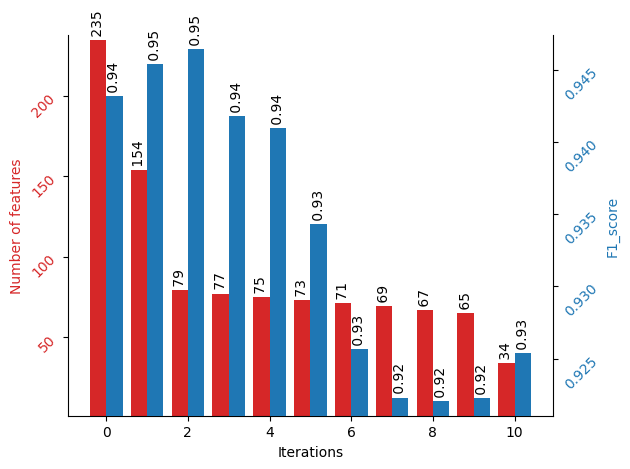

In [49]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_mlp_icafs.png')

best f1 score= 0.9832679738562092, iteration:1, numbers features selected =242,best features selected=1018.856, 1036.2215, 1038.151, 1040.0815, 1042.011, 1043.9405, 1045.87, 1047.7995, 1049.729, 1051.6585, 1053.588, 1055.5175, 1057.447, 1059.3765, 1061.306, 1063.2355, 1065.165, 1067.0945, 1069.024, 1070.9535, 1072.883, 1074.8135, 1076.743, 1078.6725, 1080.602, 1082.5315, 1084.461, 1086.3905, 1088.32, 1090.2495, 1092.179, 1094.1085, 1096.038, 1097.9675, 1099.897, 1101.8265, 1103.756, 1105.6855, 1107.615, 1109.5455, 1111.475, 1113.4045, 1115.334, 1117.2635, 1119.193, 1121.1225, 1123.052, 1124.9815, 1126.911, 1128.8405, 1134.63, 1142.348, 1167.4325, 1169.362, 1171.2915, 1173.221, 1180.939, 1182.8685, 1184.798, 1186.7275, 1192.517, 1194.4465, 1198.3055, 1200.235, 1202.1645, 1206.0235, 1207.953, 1209.8825, 1211.812, 1213.7415, 1215.671, 1217.6005, 1219.53, 1221.4595, 1223.389, 1225.3195, 1227.249, 1236.8965, 1238.826, 1240.7555, 1242.685, 1250.404, 1252.3335, 1258.122, 1265.84, 1290.9245, 1

<Figure size 1100x1000 with 0 Axes>

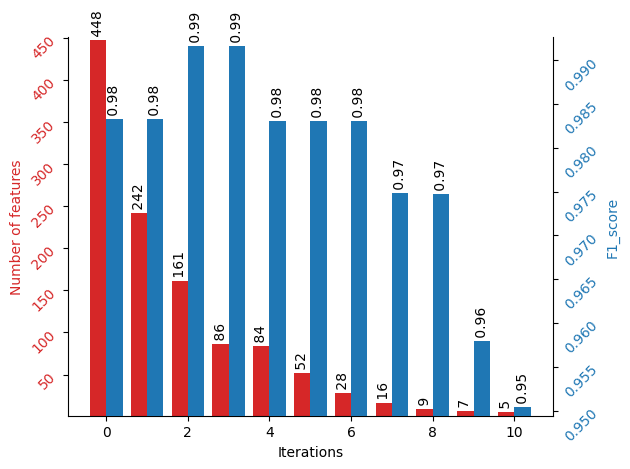

In [50]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_mlp_icafs.png')

best f1 score= 0.92739898989899, iteration:1, numbers features selected =367,best features selected=812.3985, 860.636, 862.5655, 864.495, 866.4245, 868.354, 870.2835, 872.213, 874.1425, 876.072, 878.0015, 879.931, 881.8605, 883.79, 885.7195, 887.649, 889.5785, 891.508, 893.4375, 895.367, 897.2965, 899.226, 901.1555, 903.085, 905.0145, 906.944, 908.8735, 910.803, 912.7325, 914.662, 916.5915, 918.521, 920.4505, 922.38, 924.3095, 926.239, 928.1685, 930.098, 932.0275, 933.957, 935.8865, 937.816, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 949.394, 951.3235, 953.253, 955.1825, 957.112, 959.0415, 960.971, 962.9005, 964.83, 966.7595, 968.689, 970.6185, 972.548, 974.4775, 976.407, 978.3365, 980.266, 982.1955, 984.125, 986.0545, 987.984, 989.9135, 991.843, 993.7725, 995.702, 997.6315, 999.561, 1001.4905, 1003.42, 1005.3495, 1007.279, 1009.2085, 1011.138, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1022.715, 1024.6445, 1026.574, 1028.5035, 1030.433, 1032.3625, 1034.292, 1036.2215, 1

<Figure size 1100x1000 with 0 Axes>

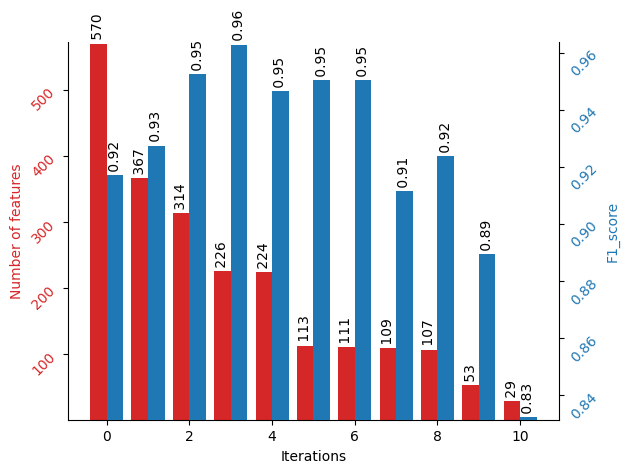

In [51]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs_mlp.png')

# Best t subset of features

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_box_plot(data,title_x,title_y,main_title):
    # Create a figure and axes for the plot
    fig, ax = plt.subplots(figsize=(4, 4))

    # --- Data Generation ---
    # Generate sample data for six distinct groups.
    # In a real scenario, you would replace this with your actual data.
    df = pd.DataFrame(data)

    # --- Plotting and Aesthetics ---
    # Define a professional and aesthetically pleasing color palette.
    # The 'viridis' palette is colorblind-friendly and prints well in grayscale.
    palette = sns.color_palette("viridis", n_colors=6)

    # Create the boxplots with enhanced aesthetics
    sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,
                boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='black', linewidth=2, solid_capstyle="round"),
                flierprops=dict(marker='v', markerfacecolor='gray', markersize=8, alpha=0.7, markeredgecolor='black'))

    # Add individual data points for better visualization, especially with small sample sizes.
    sns.stripplot(data=df, ax=ax, color='black', alpha=0.5, jitter=0.2, size=2)


    # --- Labels, Title, and Grid ---
    # Add a subtle background grid for improved readability.
    ax.yaxis.grid(True, linestyle='--', which='major', color='lightgrey', alpha=0.7)
    ax.set_axisbelow(True) # Ensure grid is behind the boxes

    # Set eye-catching and informative labels and title.
    ax.set_title(main_title,fontsize=10, fontweight='bold', pad=25)
    ax.set_ylabel(title_y, fontsize=10, fontweight='bold')
    ax.set_xlabel(title_x, fontsize=10, fontweight='bold')

    # --- Final Touches ---
    # Customize tick parameters for a cleaner look.
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Remove the top and right spines for a cleaner, modern look (Tufte's principle).
    sns.despine(trim=True, left=True)

    # Ensure all elements fit within the figure cleanly.
    plt.tight_layout()

    # --- Display the Plot ---
    # To save the figure for your paper, you can use:
    # plt.savefig("scientific_boxplot.png", dpi=300, bbox_inches='tight')

    plt.show()

### wbc dataset

In [79]:


import pandas as pd

# Define the column names in a list, in the correct order
column_names = [
    'id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean',
    'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se',
    'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se',
    'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst',
    'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst',
    'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Load the data and assign the column names
# Replace 'path/to/wdbc.data' with the actual file path
df_wbc = pd.read_csv('../data/data_temp/wdbc.data', header=None, names=column_names)

unique_wbc = df_wbc["diagnosis"].unique()
wbc_x = df_wbc.iloc[:,2:]
y_wbc = df_wbc.iloc[:,1:2].replace(to_replace=unique_wbc, value =range(0,len(unique_wbc)))
X_wbc = (wbc_x-wbc_x.min())/(wbc_x.max()-wbc_x.min())



C:\Users\robma\AppData\Local\Temp\ipykernel_16916\1701725950.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_wbc = df_wbc.iloc[:,1:2].replace(to_replace=unique_wbc, value =range(0,len(unique_wbc)))


### knn

In [94]:
my_dict_knn_wbc = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_wbc,y_wbc,t,10,'KNeighborsClassifier(n_neighbors=3)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_wbc[t] = float_scores

testing with strenght :2
best f1 score= 0.9641232917141991, iteration:1, numbers features selected =18,best features selected=area_mean, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst
best f1 score= 0.9661932041197833, iteration:2, numbers features selected =10,best features selected=perimeter_se, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst
best f1 score= 0.9473374233456514, iteration:3, numbers features selected =6,best features selected=perimeter_se, texture_worst, perimeter_worst, smoothness_worst, concavity_worst, symmetry_worst
best f1 score= 0.9398349872111934, iteration:4, numbers features selected =4,best features selected=perimeter_worst, s

## svc

In [95]:
my_dict_svc_wbc = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_wbc,y_wbc,t,10,'svm.SVC()',True)
    float_scores = [x.item() for x in score]
    my_dict_svc_wbc[t] = float_scores

testing with strenght :2
best f1 score= 0.9774733447581168, iteration:1, numbers features selected =15,best features selected=concave points_mean, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst
best f1 score= 0.9718350411107466, iteration:2, numbers features selected =13,best features selected=concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst
best f1 score= 0.9717494104006283, iteration:3, numbers features selected =11,best features selected=fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_d

In [99]:
import pickle

dict_knn_wbc_file = '../data/metadata/knn_wbc.pkl'
dict_svc_wbc_file = '../data/metadata/svc_wbc.pkl'

with open(dict_knn_wbc_file, 'wb') as file:
    pickle.dump(my_dict_knn_wbc, file)
    
with open(dict_svc_wbc_file, 'wb') as file:
    pickle.dump(my_dict_svc_wbc, file)

In [165]:
with open(dict_knn_wbc_file, 'rb') as file:
    knn_wbc = pickle.load(file)
with open(dict_svc_wbc_file, 'rb') as file:
    svc_wbc = pickle.load(file)


C:\Users\robma\AppData\Local\Temp\ipykernel_16916\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


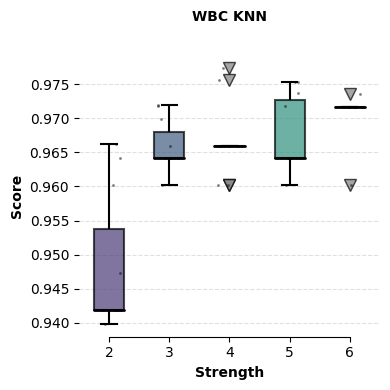

In [166]:
plot_box_plot(knn_wbc,"Strength","Score","WBC KNN")

C:\Users\robma\AppData\Local\Temp\ipykernel_16916\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


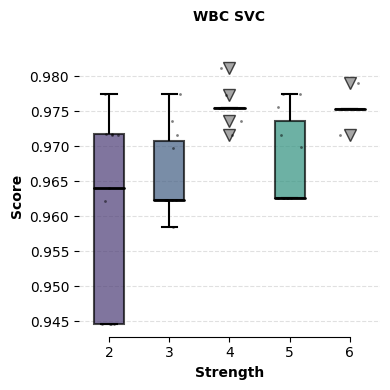

In [167]:
plot_box_plot(svc_wbc,"Strength","Score","WBC SVC")

## preparing wine dataset

In [ ]:
df_wine_red = pd.read_csv('../data/data_temp/winequality-red.csv', sep=";")
df_wine_white = pd.read_csv('../data/data_temp/winequality-white.csv', sep=";")

In [ ]:

df_wine_white = df_wine_white.iloc[:, :-1]
df_wine_red = df_wine_red.iloc[:, :-1] 

df_wine_white['type'] = "white"
df_wine_red['type']  = "red"

df_wine_all = pd.concat([df_wine_white, df_wine_red])
df_wine_final = df_wine_all.sample(frac=1)

unique_winei = df_wine_final["type"].unique()
winei_x = df_wine_final.iloc[:,0:-1]
y_winei = df_wine_final.iloc[:,-1:].replace(to_replace=unique_winei, value =range(0,len(unique_winei)))
X_winei = (winei_x-winei_x.min())/(winei_x.max()-winei_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_16916\2053552452.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_winei = df_wine_final.iloc[:,-1:].replace(to_replace=unique_winei, value =range(0,len(unique_winei)))


In [96]:
my_dict_knn_wine = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_winei,y_winei,t,10,'KNeighborsClassifier(n_neighbors=2)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_wine[t] = float_scores

testing with strenght :2
best f1 score= 0.9887071598888315, iteration:1, numbers features selected =9,best features selected=citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
best f1 score= 0.9874583190434192, iteration:2, numbers features selected =7,best features selected=chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
best f1 score= 0.9742962413888531, iteration:3, numbers features selected =5,best features selected=chlorides, free sulfur dioxide, total sulfur dioxide, pH, alcohol
best f1 score= 0.9657819066679538, iteration:4, numbers features selected =4,best features selected=chlorides, free sulfur dioxide, total sulfur dioxide, alcohol
best f1 score= 0.9601740272085613, iteration:5, numbers features selected =3,best features selected=chlorides, free sulfur dioxide, total sulfur dioxide
best f1 score= 0.9601740272085613, iteration:6, numbers features selected =3,best features se

In [97]:
my_dict_svc_wine = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_winei,y_winei,t,10,'svm.SVC()',True)
    float_scores = [x.item() for x in score]
    my_dict_svc_wine[t] = float_scores

testing with strenght :2
best f1 score= 0.9941690199482671, iteration:1, numbers features selected =9,best features selected=citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol
best f1 score= 0.9876635096366304, iteration:2, numbers features selected =6,best features selected=residual sugar, free sulfur dioxide, total sulfur dioxide, density, sulphates, alcohol
best f1 score= 0.968302699019606, iteration:3, numbers features selected =4,best features selected=total sulfur dioxide, density, sulphates, alcohol
best f1 score= 0.9632390217388359, iteration:4, numbers features selected =3,best features selected=total sulfur dioxide, density, sulphates
best f1 score= 0.9632390217388359, iteration:5, numbers features selected =3,best features selected=total sulfur dioxide, density, sulphates
best f1 score= 0.9632390217388359, iteration:6, numbers features selected =3,best features selected=total sulfur dioxide, density, sulphates
b

In [ ]:
import pickle

dict_knn_wine_file = '../data/metadata/knn_wine.pkl'
dict_svc_wine_file = '../data/metadata/svc_wine.pkl'

with open(dict_knn_wine_file, 'wb') as file:
    pickle.dump(my_dict_knn_wine, file)
    
with open(dict_svc_wine_file, 'wb') as file:
    pickle.dump(my_dict_svc_wine, file)



In [ ]:
with open(dict_knn_wine_file, 'rb') as file:
    knn_wine = pickle.load(file)
with open(dict_svc_wine_file, 'rb') as file:
    svc_wine = pickle.load(file)


{2: [0.9891717585381977, 0.9887071598888315, 0.9874583190434192, 0.9742962413888531, 0.9657819066679538, 0.9601740272085613, 0.9601740272085613, 0.9601740272085613, 0.9601740272085613, 0.9601740272085613, 0.9601740272085613], 3: [0.9891717585381977, 0.9885055446592388, 0.9859581282261649, 0.9855270408209742, 0.9772809149826586, 0.9772809149826586, 0.9772809149826586, 0.9772809149826586, 0.9772809149826586, 0.9772809149826586, 0.9772809149826586], 4: [0.9891717585381977, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327, 0.987458772113327], 5: [0.9891717585381977, 0.9906366297410829, 0.9904258462562161, 0.9901810827777684, 0.9895464858079579, 0.9895464858079579, 0.9895464858079579, 0.9895464858079579, 0.9895464858079579, 0.9895464858079579, 0.9895464858079579], 6: [0.9891717585381977, 0.9901971480270388, 0.9904258462562161, 0.9904258462562161, 0.9904258462562161, 0.990

C:\Users\robma\AppData\Local\Temp\ipykernel_16916\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


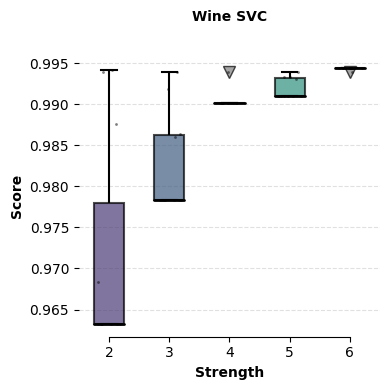

In [163]:
plot_box_plot(svc_wine,"Strength","Score","Wine SVC")

C:\Users\robma\AppData\Local\Temp\ipykernel_16916\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


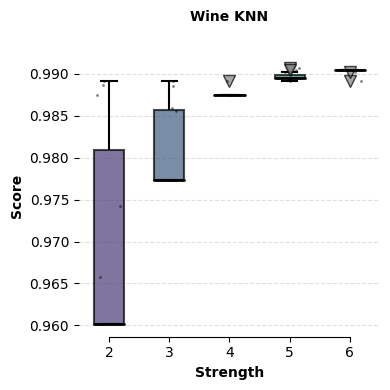

In [164]:
plot_box_plot(knn_wine,"Strength","Score","Wine KNN")

# preparing mushrom dataset

In [ ]:
column_names_mush_room = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape',
    'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]

full_name_mappings = {
    'class': {'p': 'poisonous', 'e': 'edible'},
    'cap-shape': {'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat', 'k': 'knobbed', 's': 'sunken'},
    'cap-surface': {'f': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth'},
    'cap-color': {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'r': 'green', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'},
    'bruises': {'t': 'bruises', 'f': 'no-bruises'},
    'odor': {'a': 'almond', 'l': 'anise', 'c': 'creosote', 'y': 'fishy', 'f': 'foul', 'm': 'musty', 'n': 'none', 'p': 'pungent', 's': 'spicy'},
    'gill-attachment': {'a': 'attached', 'd': 'descending', 'f': 'free', 'n': 'notched'},
    'gill-spacing': {'c': 'close', 'w': 'crowded', 'd': 'distant'},
    'gill-size': {'b': 'broad', 'n': 'narrow'},
    'gill-color': {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'g': 'gray', 'r': 'green', 'o': 'orange', 'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow'},
    'stalk-shape': {'e': 'enlarging', 't': 'tapering'},
    'stalk-root': {'b': 'bulbous', 'c': 'club', 'u': 'cup', 'e': 'equal', 'z': 'rhizomorphs', 'r': 'rooted', '?': 'missing'},
    'stalk-surface-above-ring': {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'},
    'stalk-surface-below-ring': {'f': 'fibrous', 'y': 'scaly', 'k': 'silky', 's': 'smooth'},
    'stalk-color-above-ring': {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'},
    'stalk-color-below-ring': {'n': 'brown', 'b': 'buff', 'c': 'cinnamon', 'g': 'gray', 'o': 'orange', 'p': 'pink', 'e': 'red', 'w': 'white', 'y': 'yellow'},
    'veil-type': {'p': 'partial', 'u': 'universal'},
    'veil-color': {'n': 'brown', 'o': 'orange', 'w': 'white', 'y': 'yellow'},
    'ring-number': {'n': 'none', 'o': 'one', 't': 'two'},
    'ring-type': {'c': 'cobwebby', 'e': 'evanescent', 'f': 'flaring', 'l': 'large', 'n': 'none', 'p': 'pendant', 's': 'sheathing', 'z': 'zone'},
    'spore-print-color': {'k': 'black', 'n': 'brown', 'b': 'buff', 'h': 'chocolate', 'r': 'green', 'o': 'orange', 'p': 'purple', 'u': 'red', 'w': 'white', 'y': 'yellow'},
    'population': {'a': 'abundant', 'c': 'clustered', 'n': 'numerous', 's': 'scattered', 'v': 'several', 'y': 'solitary'},
    'habitat': {'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths', 'u': 'urban', 'w': 'waste', 'd': 'woods'}
}


df_mushrom = pd.read_csv( '../data/data_temp/agaricus-lepiota.csv', header=None, names=column_names_mush_room, na_values='?')
df_mushrom = df_mushrom.dropna()
df_mushrom = df_mushrom.replace(full_name_mappings)

unique_mush = df_mushrom["class"].unique()
mush_x = df_mushrom.iloc[:,1:]
y_mush = df_mushrom.iloc[:,:1].replace(to_replace=unique_mush, value =range(0,len(unique_mush)))

mush_encoded = pd.get_dummies(mush_x, dtype=int)
#mush_encoded = mush_encoded.reset_index()
#X_mush = (winei_x-winei_x.min())/(winei_x.max()-winei_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_16916\1443940726.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_mush = df_mushrom.iloc[:,:1].replace(to_replace=unique_mush, value =range(0,len(unique_mush)))


In [98]:
my_dict_knn_mush = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(mush_encoded,y_mush,t,10,'KNeighborsClassifier(n_neighbors=2)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_mush[t] = float_scores

testing with strenght :2
best f1 score= 0.9724118055791375, iteration:1, numbers features selected =50,best features selected=cap-shape_convex, cap-surface_grooves, cap-surface_smooth, cap-color_brown, cap-color_cinnamon, cap-color_gray, cap-color_pink, cap-color_red, cap-color_white, bruises_bruises, bruises_no-bruises, odor_almond, odor_none, gill-attachment_attached, gill-spacing_close, gill-spacing_crowded, gill-size_broad, gill-size_narrow, gill-color_brown, gill-color_chocolate, gill-color_gray, gill-color_yellow, stalk-root_club, stalk-root_equal, stalk-root_rooted, stalk-surface-above-ring_fibrous, stalk-surface-above-ring_silky, stalk-surface-above-ring_smooth, stalk-surface-below-ring_fibrous, stalk-color-above-ring_buff, stalk-color-above-ring_white, stalk-color-above-ring_yellow, stalk-color-below-ring_brown, stalk-color-below-ring_buff, stalk-color-below-ring_gray, stalk-color-below-ring_pink, stalk-color-below-ring_white, ring-number_none, ring-type_large, ring-type_none,

KeyboardInterrupt: 

In [103]:
my_dict_svc_mush = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(mush_encoded,y_mush,t,10,'svm.SVC()',True)
    float_scores = [x.item() for x in score]
    my_dict_svc_mush[t] = float_scores

testing with strenght :2


KeyboardInterrupt: 

## Abalone Dataset

In [1]:
!pip install pandas scikit-learn imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd

# Define the column names for the E. coli dataset
column_names = [
    'sequence_name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

# Load the dataset from a local file or URL
# Note: You might need to change the file path to where you've saved the data.
# UCI Machine Learning Repository URL for the dataset:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data'

df_abolone = pd.read_csv(url, delim_whitespace=True, header=None, names=column_names)

# Display the first few rows and the class distribution
print("Original Dataset Shape:", df.shape)
print("\nOriginal Class Distribution:")
print(df_abolone['class'].value_counts())

C:\Users\robma\AppData\Local\Temp\ipykernel_18512\1004510925.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_abolone = pd.read_csv(url, delim_whitespace=True, header=None, names=column_names)


Original Dataset Shape: (336, 8)

Original Class Distribution:
class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imL      2
imS      2
Name: count, dtype: int64


In [30]:
df_abolone


,sequence_name,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
...,...,...,...,...,...,...,...,...,...
331,TREA_ECOLI,0.74,0.56,0.48,0.5,0.47,0.68,0.30,pp
332,UGPB_ECOLI,0.71,0.57,0.48,0.5,0.48,0.35,0.32,pp
333,USHA_ECOLI,0.61,0.60,0.48,0.5,0.44,0.39,0.38,pp
334,XYLF_ECOLI,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp


In [31]:
df_abolone = df_abolone.drop('sequence_name', axis=1)

# Separate features (X) and the target variable (y)
x_abolone = df_abolone.drop('class', axis=1)
y_abolone = df_abolone['class']

unique_abolone = df_abolone['class'].unique()
abolone_x = df_abolone.iloc[:,0:-1]
y_abolone = df_abolone.iloc[:,-1:].replace(to_replace=unique_abolone, value =range(0,len(unique_abolone)))
X_abolone = (abolone_x-abolone_x.min())/(abolone_x.max()-abolone_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_18512\1298414933.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_abolone = df_abolone.iloc[:,-1:].replace(to_replace=unique_abolone, value =range(0,len(unique_abolone)))


In [38]:
my_dict_knn_avolone = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_abolone,y_abolone,t,10,'KNeighborsClassifier(n_neighbors=2)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_avolone[t] = float_scores

testing with strenght :2


d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


KeyboardInterrupt: 

## Avolone 

In [79]:
import pandas as pd

# Define column names
column_names = [
    'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
    'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'
]

# Load the dataset from the UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
df_abolone = pd.read_csv(url, header=None, names=column_names)

# One-hot encode the 'Sex' categorical feature
df_abolone = pd.get_dummies(df_abolone, columns=['Sex'], drop_first=True,dtype=int)

print("Original dataset shape:", df_abolone.shape)
df_abolone.head()

Original dataset shape: (4177, 10)


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,1,0


In [80]:
# Define the bins for the 'Rings' column
# Let's say: Young <= 8, Adult is 9 or 10, Old is >= 11
bins = [0, 8, 10, 30]
labels = ['Young', 'Adult', 'Old']

median_rings = df_abolone['Rings'].median()
# Create the new binned target column
df_abolone['Age_Group'] = df_abolone['Rings'].apply(lambda x: "old" if x > median_rings else "young")

# Now we drop the original 'Rings' column as we have our new target
df_abolone = df_abolone.drop('Rings', axis=1)

# --- CRUCIAL: Check the class distribution ---
print("\nNew Class Distribution (Imbalanced):")
print(df_abolone['Age_Group'].value_counts())


New Class Distribution (Imbalanced):
Age_Group
young    2096
old      2081
Name: count, dtype: int64


In [84]:
df_abolone

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M,Age_Group
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,0,1,old
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,0,1,young
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,0,0,young
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,0,1,old
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,1,0,young
...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,0,0,old
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,0,1,old
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,0,1,young
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,0,0,old


In [100]:
unique_abolone = df_abolone['Age_Group'].unique()
abolone_x = df_abolone.iloc[:,0:-1]
y_abolone = df_abolone.iloc[:,-1:].replace(to_replace=unique_abolone, value =range(0,len(unique_abolone)))
X_abolone = (abolone_x.iloc[:,0:-2]-abolone_x.iloc[:,0:-2].min())/(abolone_x.iloc[:,0:-2].max()-abolone_x.iloc[:,0:-2].min())
X_abolone_extra =abolone_x.iloc[:,7:]

C:\Users\robma\AppData\Local\Temp\ipykernel_18512\3610874601.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_abolone = df_abolone.iloc[:,-1:].replace(to_replace=unique_abolone, value =range(0,len(unique_abolone)))


In [110]:
X_abolone = pd.concat([X_abolone, X_abolone_extra], axis=1)

In [131]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

my_dict_knn_avolone = {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_abolone,y_abolone,t,10,'KNeighborsClassifier(n_neighbors=3)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_avolone[t] = float_scores

testing with strenght :2
best f1 score= 0.7458995857712851, iteration:1, numbers features selected =7,best features selected=Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight, Sex_I, Sex_M
best f1 score= 0.741727719086785, iteration:2, numbers features selected =5,best features selected=Shucked_weight, Viscera_weight, Shell_weight, Sex_I, Sex_M
best f1 score= 0.7342245177140247, iteration:3, numbers features selected =1,best features selected=Shell_weight
best f1 score= 0.7342245177140247, iteration:4, numbers features selected =1,best features selected=Shell_weight
best f1 score= 0.7342245177140247, iteration:5, numbers features selected =1,best features selected=Shell_weight
best f1 score= 0.7342245177140247, iteration:6, numbers features selected =1,best features selected=Shell_weight
best f1 score= 0.7342245177140247, iteration:7, numbers features selected =1,best features selected=Shell_weight
best f1 score= 0.7342245177140247, iteration:8, numbers features select

## Letter Recognition

In [115]:
import pandas as pd

# Define the column names based on the dataset's description on the UCI page
column_names = [
    'letter', 'x-box', 'y-box', 'width', 'height', 'onpix', 'x-bar',
    'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege',
    'xegvy', 'y-ege', 'yegvx'
]

# Provide the direct URL to the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data'

# Load the dataset using pandas
letter_df = pd.read_csv(url, header=None, names=column_names)

In [124]:

unique_letter = letter_df['letter'].unique()
letter_x = letter_df.iloc[:,1:]
y_letter = letter_df.iloc[:,0:1].replace(to_replace=unique_letter, value =range(0,len(unique_letter)))
X_letter = (letter_x-letter_x.min())/(letter_x.max()-letter_x.min())


C:\Users\robma\AppData\Local\Temp\ipykernel_18512\3207425817.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_letter = letter_df.iloc[:,0:1].replace(to_replace=unique_letter, value =range(0,len(unique_letter)))


In [130]:
my_dict_knn_letter= {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_letter,y_letter,t,10,'KNeighborsClassifier(n_neighbors=3)',True)
    float_scores = [x.item() for x in score]
    my_dict_knn_letter[t] = float_scores

testing with strenght :2
best f1 score= 0.9542513927632591, iteration:1, numbers features selected =14,best features selected=width, height, onpix, x-bar, y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.9579633072650362, iteration:2, numbers features selected =12,best features selected=onpix, x-bar, y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.9573035276391464, iteration:3, numbers features selected =10,best features selected=y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.9266507276888785, iteration:4, numbers features selected =8,best features selected=y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.814022987986333, iteration:5, numbers features selected =6,best features selected=x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.6629694224848043, iteration:6, numbers features selected =4,best features selected=x2ybr, xy2br, x-ege, y-ege


C:\Users\robma\AppData\Local\Temp\ipykernel_18512\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


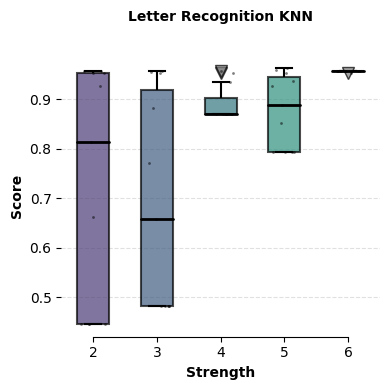

In [134]:
plot_box_plot(my_dict_knn_letter,"Strength","Score","Letter Recognition KNN")

In [136]:
my_dict_svc_letter= {}
max_strength = 6
for t in range(2,max_strength +1):
    print(f"testing with strenght :{t}")
    iterations ,feature,score = ICAFS(X_letter,y_letter,t,10,'svm.SVC()',True)
    float_scores = [x.item() for x in score]
    my_dict_svc_letter[t] = float_scores

testing with strenght :2
best f1 score= 0.9196434403243711, iteration:1, numbers features selected =14,best features selected=width, height, onpix, x-bar, y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.9087709166278204, iteration:2, numbers features selected =12,best features selected=onpix, x-bar, y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.8981239849726389, iteration:3, numbers features selected =10,best features selected=y-bar, x2bar, y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.8382801074864672, iteration:4, numbers features selected =8,best features selected=y2bar, xybar, x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.7088071109906172, iteration:5, numbers features selected =6,best features selected=x2ybr, xy2br, x-ege, xegvy, y-ege, yegvx
best f1 score= 0.6087880093336204, iteration:6, numbers features selected =4,best features selected=x2ybr, xy2br, x-ege, y-ege

In [ ]:
import pickle

dict_svc_letter_file = '../data/metadata/svc_letter.pkl'

with open(dict_svc_letter_file, 'wb') as file:
    pickle.dump(my_dict_svc_letter, file)

C:\Users\robma\AppData\Local\Temp\ipykernel_18512\2128212339.py:21: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(data=df, ax=ax, palette=palette, width=0.5,


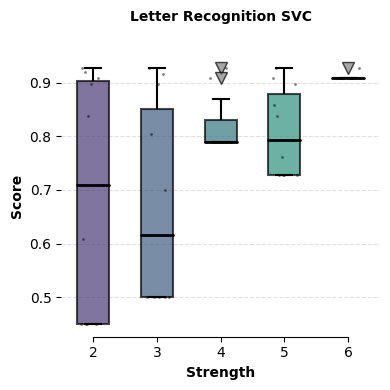

In [138]:
plot_box_plot(my_dict_svc_letter,"Strength","Score","Letter Recognition SVC")